<a href="https://colab.research.google.com/github/yashaskiran/computer_vision_projects/blob/main/Performance_Analysis_and_Optimization_of_UAV_Assisted_Wireless_Communication_Systems_with_Dynamic_Trajectory_Planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SEGMENT 1: Import Libraries and Initial Setup
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.spatial import distance
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print("📡 Drone-Based Wireless Communication Simulator")
print("="*60)

✅ All libraries imported successfully!
📡 Drone-Based Wireless Communication Simulator


In [ ]:
# ============================================================
# SEGMENT 2: System Parameters Configuration
# ============================================================

class DroneCommSystem:
    """
    Complete Drone-Based Wireless Communication System Configuration
    Based on ITU-R and 3GPP air-to-ground channel models
    """

    def __init__(self):
        # === Frequency and Power Parameters ===
        self.fc = 2.4e9  # Carrier frequency in Hz (2.4 GHz)
        self.Pt_dBm = 30  # Transmit power in dBm (1 Watt)
        self.Pt = 10**((self.Pt_dBm - 30) / 10)  # Convert to Watts

        # === Antenna Parameters ===
        self.Gt_dB = 5  # Transmitter antenna gain (dB)
        self.Gr_dB = 0  # Receiver antenna gain (dB)
        self.Gt = 10**(self.Gt_dB / 10)
        self.Gr = 10**(self.Gr_dB / 10)

        # === Environment Parameters (ITU Model) ===
        # Urban environment parameters for LOS probability
        self.mu_a = 9.61  # Environment parameter (urban)
        self.mu_b = 0.16  # Environment parameter (urban)

        # === Path Loss Exponents ===
        self.alpha_LOS = 2.0  # Free space path loss exponent
        self.alpha_NLOS = 2.8  # NLOS path loss exponent (higher attenuation)

        # === Shadowing Parameters ===
        self.sigma_LOS = 1.0  # Shadowing standard deviation for LOS (dB)
        self.sigma_NLOS = 4.2  # Shadowing standard deviation for NLOS (dB)

        # === Noise and Interference ===
        self.bandwidth = 20e6  # Channel bandwidth (20 MHz)
        self.noise_figure_dB = 7  # Receiver noise figure
        self.T0 = 290  # Reference temperature (Kelvin)
        self.k_boltzmann = 1.38e-23  # Boltzmann constant

        # Calculate noise power
        self.N0_dBm = -174  # Noise power spectral density (dBm/Hz)
        self.noise_power_dBm = self.N0_dBm + 10*np.log10(self.bandwidth) + self.noise_figure_dB
        self.noise_power = 10**((self.noise_power_dBm - 30) / 10)  # Watts

        # === UAV/Drone Parameters ===
        self.h_min = 50  # Minimum altitude (m)
        self.h_max = 500  # Maximum altitude (m)
        self.velocity = 15  # Drone velocity (m/s)

        # === Simulation Area ===
        self.area_size = 1000  # Square area size (m x m)
        self.grid_resolution = 50  # Grid points for heatmap

        # === Physical Constants ===
        self.c = 3e8  # Speed of light (m/s)
        self.wavelength = self.c / self.fc

    def display_parameters(self):
        """Display all system parameters"""
        print("\n📋 SYSTEM CONFIGURATION")
        print("="*60)
        print(f"🔹 Carrier Frequency: {self.fc/1e9:.2f} GHz")
        print(f"🔹 Transmit Power: {self.Pt_dBm} dBm ({self.Pt*1000:.2f} mW)")
        print(f"🔹 Bandwidth: {self.bandwidth/1e6:.1f} MHz")
        print(f"🔹 Noise Power: {self.noise_power_dBm:.2f} dBm")
        print(f"🔹 Wavelength: {self.wavelength*100:.2f} cm")
        print(f"🔹 Altitude Range: {self.h_min}m - {self.h_max}m")
        print(f"🔹 Coverage Area: {self.area_size}m × {self.area_size}m")
        print(f"🔹 Drone Velocity: {self.velocity} m/s")
        print(f"🔹 Environment: Urban (μa={self.mu_a}, μb={self.mu_b})")
        print("="*60)

# Initialize system
system = DroneCommSystem()
system.display_parameters()


📋 SYSTEM CONFIGURATION
🔹 Carrier Frequency: 2.40 GHz
🔹 Transmit Power: 30 dBm (1000.00 mW)
🔹 Bandwidth: 20.0 MHz
🔹 Noise Power: -93.99 dBm
🔹 Wavelength: 12.50 cm
🔹 Altitude Range: 50m - 500m
🔹 Coverage Area: 1000m × 1000m
🔹 Drone Velocity: 15 m/s
🔹 Environment: Urban (μa=9.61, μb=0.16)


In [ ]:
# ============================================================
# SEGMENT 3: Air-to-Ground Channel Model
# ============================================================

class A2GChannelModel:
    """
    Air-to-Ground Channel Model based on ITU-R recommendations
    Includes LOS probability, path loss, and shadowing effects
    """

    def __init__(self, system_params):
        self.sys = system_params

    def compute_distance_3d(self, drone_pos, user_pos):
        """
        Compute 3D Euclidean distance between drone and user
        drone_pos: [x, y, z] in meters
        user_pos: [x, y, 0] in meters (ground level)
        """
        return np.sqrt((drone_pos[0] - user_pos[0])**2 +
                      (drone_pos[1] - user_pos[1])**2 +
                      drone_pos[2]**2)

    def compute_elevation_angle(self, drone_height, horizontal_dist):
        """
        Compute elevation angle in degrees
        """
        if horizontal_dist == 0:
            return 90.0
        return np.degrees(np.arctan(drone_height / horizontal_dist))

    def los_probability(self, drone_height, distance_3d):
        """
        ITU-R LOS probability model
        P_LOS = 1 / (1 + μa * exp(-μb * (θ - μa)))
        where θ is elevation angle in degrees
        """
        horizontal_dist = np.sqrt(distance_3d**2 - drone_height**2)

        if horizontal_dist < 1e-6:  # Directly below drone
            return 1.0

        # Elevation angle in degrees
        theta = np.degrees(np.arcsin(drone_height / distance_3d))

        # ITU-R model
        exponent = -self.sys.mu_b * (theta - self.sys.mu_a)
        p_los = 1.0 / (1.0 + self.sys.mu_a * np.exp(exponent))

        return np.clip(p_los, 0, 1)

    def free_space_path_loss_dB(self, distance_3d):
        """
        Free Space Path Loss (FSPL) in dB
        FSPL = 20*log10(d) + 20*log10(f) + 20*log10(4π/c)
        """
        if distance_3d < 1:
            distance_3d = 1

        fspl = 20*np.log10(distance_3d) + 20*np.log10(self.sys.fc) + \
               20*np.log10(4*np.pi/self.sys.c)
        return fspl

    def compute_path_loss(self, drone_pos, user_pos, include_shadowing=True):
        """
        Complete path loss calculation with LOS/NLOS consideration
        Returns: path_loss_dB, is_los
        """
        distance_3d = self.compute_distance_3d(drone_pos, user_pos)
        drone_height = drone_pos[2]

        # LOS probability
        p_los = self.los_probability(drone_height, distance_3d)

        # Determine LOS or NLOS (stochastic)
        is_los = np.random.rand() < p_los

        # Base path loss (FSPL)
        pl_base = self.free_space_path_loss_dB(distance_3d)

        # Additional path loss based on LOS/NLOS
        if is_los:
            # LOS: minimal additional loss
            additional_loss = 0
            shadowing_std = self.sys.sigma_LOS
        else:
            # NLOS: excessive path loss
            additional_loss = 20  # Additional 20 dB for NLOS
            shadowing_std = self.sys.sigma_NLOS

        # Shadowing (log-normal)
        if include_shadowing:
            shadowing = np.random.normal(0, shadowing_std)
        else:
            shadowing = 0

        total_path_loss = pl_base + additional_loss + shadowing

        return total_path_loss, is_los, p_los

    def compute_received_power_dBm(self, drone_pos, user_pos):
        """
        Compute received signal strength (RSS) in dBm
        RSS = Pt + Gt + Gr - Path_Loss
        """
        path_loss, is_los, p_los = self.compute_path_loss(drone_pos, user_pos)

        # Received power in dBm
        rx_power_dBm = self.sys.Pt_dBm + self.sys.Gt_dB + self.sys.Gr_dB - path_loss

        return rx_power_dBm, is_los, p_los

    def compute_sinr(self, rx_power_dBm, interference_dBm=None):
        """
        Compute Signal-to-Interference-plus-Noise Ratio
        SINR = P_rx / (P_noise + P_interference)
        """
        rx_power = 10**((rx_power_dBm - 30) / 10)  # Convert to Watts

        if interference_dBm is not None:
            interference = 10**((interference_dBm - 30) / 10)
        else:
            interference = 0

        sinr = rx_power / (self.sys.noise_power + interference)
        sinr_dB = 10 * np.log10(sinr)

        return sinr_dB, sinr

    def compute_data_rate(self, sinr_linear):
        """
        Shannon capacity formula
        C = B * log2(1 + SINR)
        """
        capacity_bps = self.sys.bandwidth * np.log2(1 + sinr_linear)
        capacity_mbps = capacity_bps / 1e6
        return capacity_mbps

# Initialize channel model
channel = A2GChannelModel(system)
print("\n✅ Air-to-Ground Channel Model initialized successfully!")


✅ Air-to-Ground Channel Model initialized successfully!


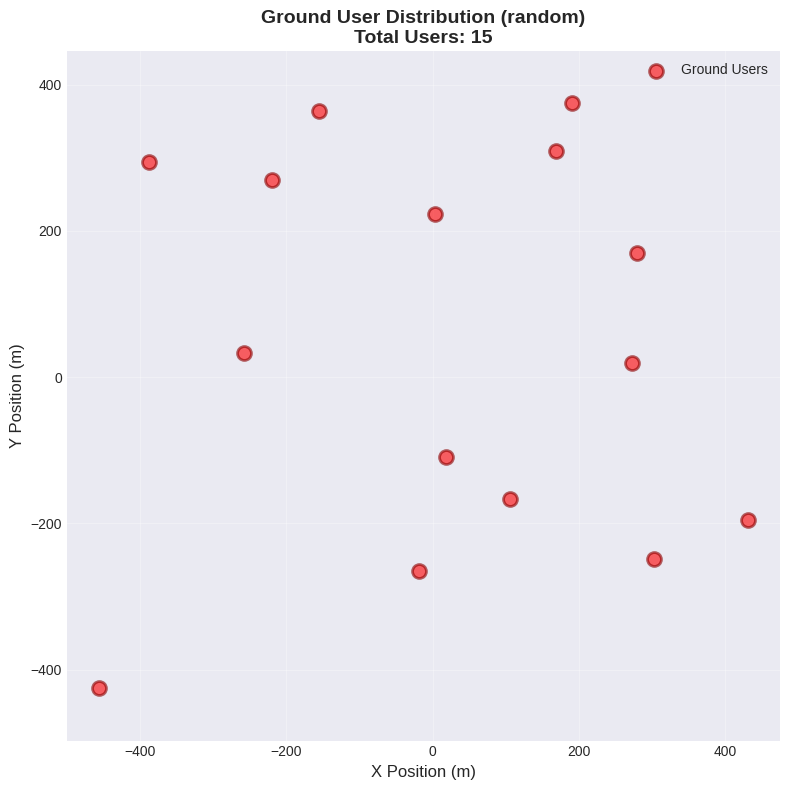


📍 Generated 15 users with 'random' distribution

✅ Multi-user scenario created successfully!


In [ ]:
# ============================================================
# SEGMENT 4: Multi-User Scenario Generation
# ============================================================

class UserScenario:
    """
    Generate and manage multiple ground users
    """

    def __init__(self, num_users, area_size, distribution='random'):
        self.num_users = num_users
        self.area_size = area_size
        self.distribution = distribution
        self.users = self.generate_users()

    def generate_users(self):
        """
        Generate user positions based on distribution type
        """
        users = []

        if self.distribution == 'random':
            # Random uniform distribution
            for i in range(self.num_users):
                x = np.random.uniform(-self.area_size/2, self.area_size/2)
                y = np.random.uniform(-self.area_size/2, self.area_size/2)
                users.append({'id': i, 'x': x, 'y': y, 'z': 0})

        elif self.distribution == 'cluster':
            # Clustered distribution (hotspots)
            num_clusters = max(3, self.num_users // 5)
            cluster_centers = []

            for _ in range(num_clusters):
                cx = np.random.uniform(-self.area_size/3, self.area_size/3)
                cy = np.random.uniform(-self.area_size/3, self.area_size/3)
                cluster_centers.append([cx, cy])

            for i in range(self.num_users):
                center = cluster_centers[i % num_clusters]
                x = center[0] + np.random.normal(0, 50)
                y = center[1] + np.random.normal(0, 50)
                users.append({'id': i, 'x': x, 'y': y, 'z': 0})

        elif self.distribution == 'grid':
            # Grid distribution
            grid_size = int(np.ceil(np.sqrt(self.num_users)))
            spacing = self.area_size / (grid_size + 1)

            idx = 0
            for i in range(grid_size):
                for j in range(grid_size):
                    if idx >= self.num_users:
                        break
                    x = -self.area_size/2 + (i+1) * spacing
                    y = -self.area_size/2 + (j+1) * spacing
                    users.append({'id': idx, 'x': x, 'y': y, 'z': 0})
                    idx += 1

        return pd.DataFrame(users)

    def visualize_users(self):
        """
        Visualize user distribution
        """
        plt.figure(figsize=(8, 8))
        plt.scatter(self.users['x'], self.users['y'],
                   c='red', s=100, marker='o', alpha=0.6,
                   edgecolors='darkred', linewidths=2, label='Ground Users')

        plt.xlim(-self.area_size/2, self.area_size/2)
        plt.ylim(-self.area_size/2, self.area_size/2)
        plt.xlabel('X Position (m)', fontsize=12)
        plt.ylabel('Y Position (m)', fontsize=12)
        plt.title(f'Ground User Distribution ({self.distribution})\nTotal Users: {self.num_users}',
                 fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10)
        plt.axis('equal')
        plt.tight_layout()
        plt.show()

        print(f"\n📍 Generated {self.num_users} users with '{self.distribution}' distribution")

# Create multi-user scenario
NUM_USERS = 15  # You can change this
user_scenario = UserScenario(num_users=NUM_USERS,
                            area_size=system.area_size,
                            distribution='random')  # Options: 'random', 'cluster', 'grid'

user_scenario.visualize_users()
print("\n✅ Multi-user scenario created successfully!")


✅ Drone trajectory generated: circular
📊 Total waypoints: 120


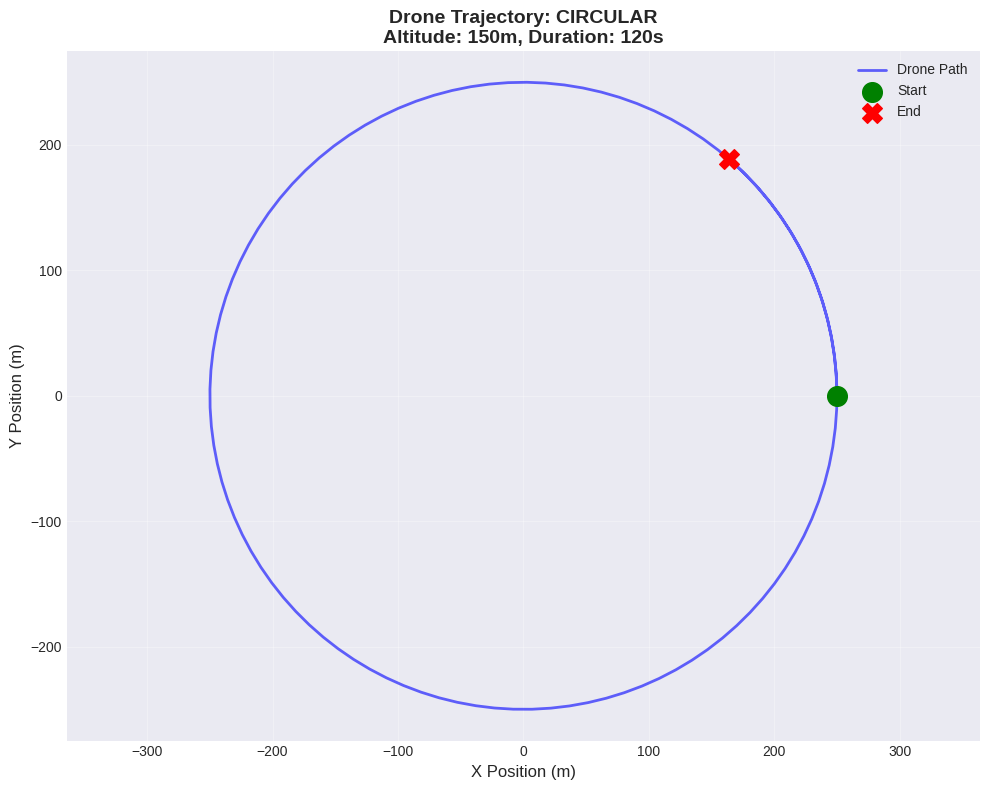

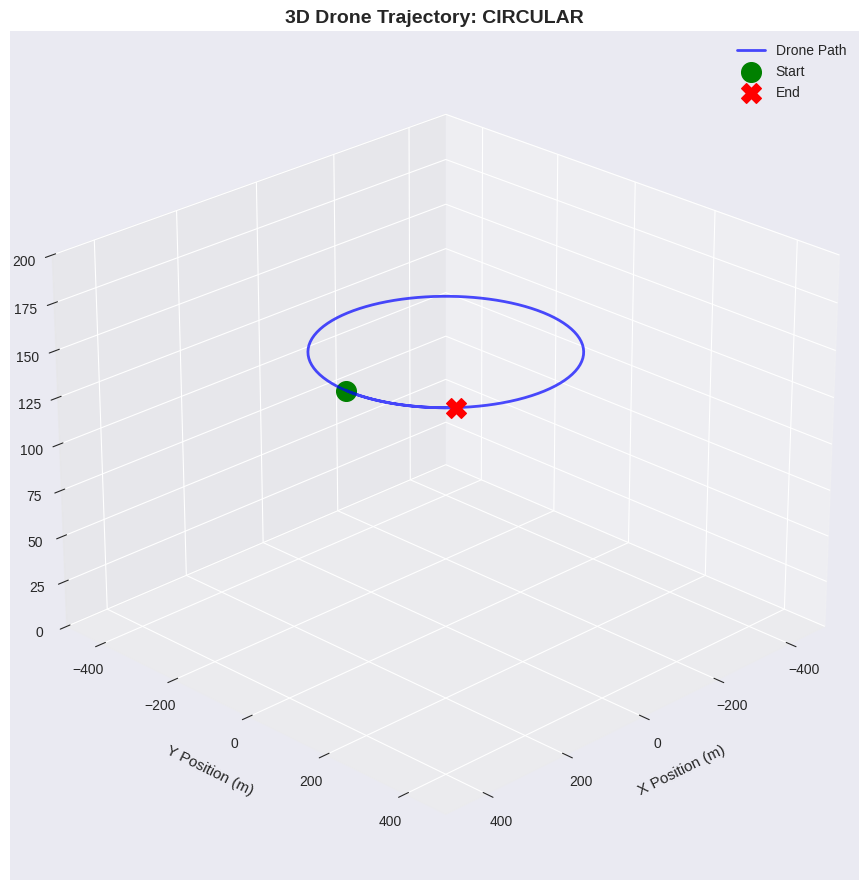

In [ ]:
# ============================================================
# SEGMENT 5: DRONE TRAJECTORY GENERATION (FIXED VERSION)
# ============================================================

class DroneTrajectory:
    """Generate different drone flight paths"""

    def __init__(self, trajectory_type='circular', altitude=150,
                 area_size=1000, velocity=15, duration=120):
        self.trajectory_type = trajectory_type
        self.altitude = altitude
        self.area_size = area_size
        self.velocity = velocity
        self.duration = duration
        self.time_step = 1.0  # seconds
        self.path = self.generate_trajectory()

    def generate_trajectory(self):
        """Generate drone trajectory based on type"""
        time_points = np.arange(0, self.duration, self.time_step)
        trajectory = []

        if self.trajectory_type == 'circular':
            radius = self.area_size / 4
            angular_velocity = self.velocity / radius  # rad/s

            for t in time_points:
                x = radius * np.cos(angular_velocity * t)
                y = radius * np.sin(angular_velocity * t)
                z = self.altitude
                trajectory.append([t, x, y, z])

        elif self.trajectory_type == 'straight':
            start_x = -self.area_size / 3
            end_x = self.area_size / 3

            for t in time_points:
                progress = (t / self.duration)
                x = start_x + progress * (end_x - start_x)
                y = 0
                z = self.altitude
                trajectory.append([t, x, y, z])

        elif self.trajectory_type == 'lawnmower':
            stripe_width = 100
            num_stripes = int(self.area_size / stripe_width)
            points_per_stripe = int(len(time_points) / num_stripes)

            stripe_idx = 0
            direction = 1

            for i, t in enumerate(time_points):
                if i > 0 and i % points_per_stripe == 0:
                    stripe_idx += 1
                    direction *= -1

                x = -self.area_size/2 + stripe_idx * stripe_width
                progress = (i % points_per_stripe) / points_per_stripe
                y = direction * (-self.area_size/2 + progress * self.area_size)
                z = self.altitude
                trajectory.append([t, x, y, z])

        elif self.trajectory_type == 'spiral':
            max_radius = self.area_size / 3

            for t in time_points:
                progress = t / self.duration
                radius = progress * max_radius
                angle = progress * 4 * np.pi  # 2 full rotations

                x = radius * np.cos(angle)
                y = radius * np.sin(angle)
                z = self.altitude
                trajectory.append([t, x, y, z])

        elif self.trajectory_type == 'hover':
            for t in time_points:
                trajectory.append([t, 0, 0, self.altitude])

        return pd.DataFrame(trajectory, columns=['time', 'x', 'y', 'z'])

    def visualize_trajectory_2d(self):
        """2D visualization of trajectory"""
        plt.figure(figsize=(10, 8))
        plt.plot(self.path['x'], self.path['y'],
                'b-', linewidth=2, alpha=0.6, label='Drone Path')
        plt.scatter(self.path['x'].iloc[0], self.path['y'].iloc[0],
                   c='green', s=200, marker='o', label='Start', zorder=5)
        plt.scatter(self.path['x'].iloc[-1], self.path['y'].iloc[-1],
                   c='red', s=200, marker='X', label='End', zorder=5)

        plt.xlim(-self.area_size/2, self.area_size/2)
        plt.ylim(-self.area_size/2, self.area_size/2)
        plt.xlabel('X Position (m)', fontsize=12)
        plt.ylabel('Y Position (m)', fontsize=12)
        plt.title(f'Drone Trajectory: {self.trajectory_type.upper()}\nAltitude: {self.altitude}m, Duration: {self.duration}s',
                 fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10)
        plt.axis('equal')
        plt.tight_layout()
        plt.show()

    def visualize_trajectory_3d(self):
        """3D visualization of trajectory - FIXED VERSION"""
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')

        ax.plot(self.path['x'], self.path['y'], self.path['z'],
               'b-', linewidth=2, alpha=0.7, label='Drone Path')
        ax.scatter(self.path['x'].iloc[0], self.path['y'].iloc[0], self.path['z'].iloc[0],
                  c='green', s=200, marker='o', label='Start')
        ax.scatter(self.path['x'].iloc[-1], self.path['y'].iloc[-1], self.path['z'].iloc[-1],
                  c='red', s=200, marker='X', label='End')

        # FIX: Set proper axis limits and labels
        ax.set_xlim([-self.area_size/2, self.area_size/2])
        ax.set_ylim([-self.area_size/2, self.area_size/2])
        ax.set_zlim([0, self.altitude + 50])  # Fixed altitude range

        ax.set_xlabel('X Position (m)', fontsize=11, labelpad=10)
        ax.set_ylabel('Y Position (m)', fontsize=11, labelpad=10)
        ax.set_zlabel('Altitude (m)', fontsize=11, labelpad=10)
        ax.set_title(f'3D Drone Trajectory: {self.trajectory_type.upper()}',
                    fontsize=14, fontweight='bold')

        # Better viewing angle
        ax.view_init(elev=25, azim=45)
        ax.legend(fontsize=10)
        plt.tight_layout()
        plt.show()

# Generate drone trajectory
TRAJECTORY_TYPE = 'circular'  # Options: 'circular', 'straight', 'lawnmower', 'spiral', 'hover'
ALTITUDE = 150  # meters
DURATION = 120  # seconds

drone_traj = DroneTrajectory(trajectory_type=TRAJECTORY_TYPE,
                            altitude=ALTITUDE,
                            area_size=system.area_size,
                            velocity=system.velocity,
                            duration=DURATION)

print(f"\n✅ Drone trajectory generated: {TRAJECTORY_TYPE}")
print(f"📊 Total waypoints: {len(drone_traj.path)}")

drone_traj.visualize_trajectory_2d()
drone_traj.visualize_trajectory_3d()


🔍 Analyzing altitude performance...


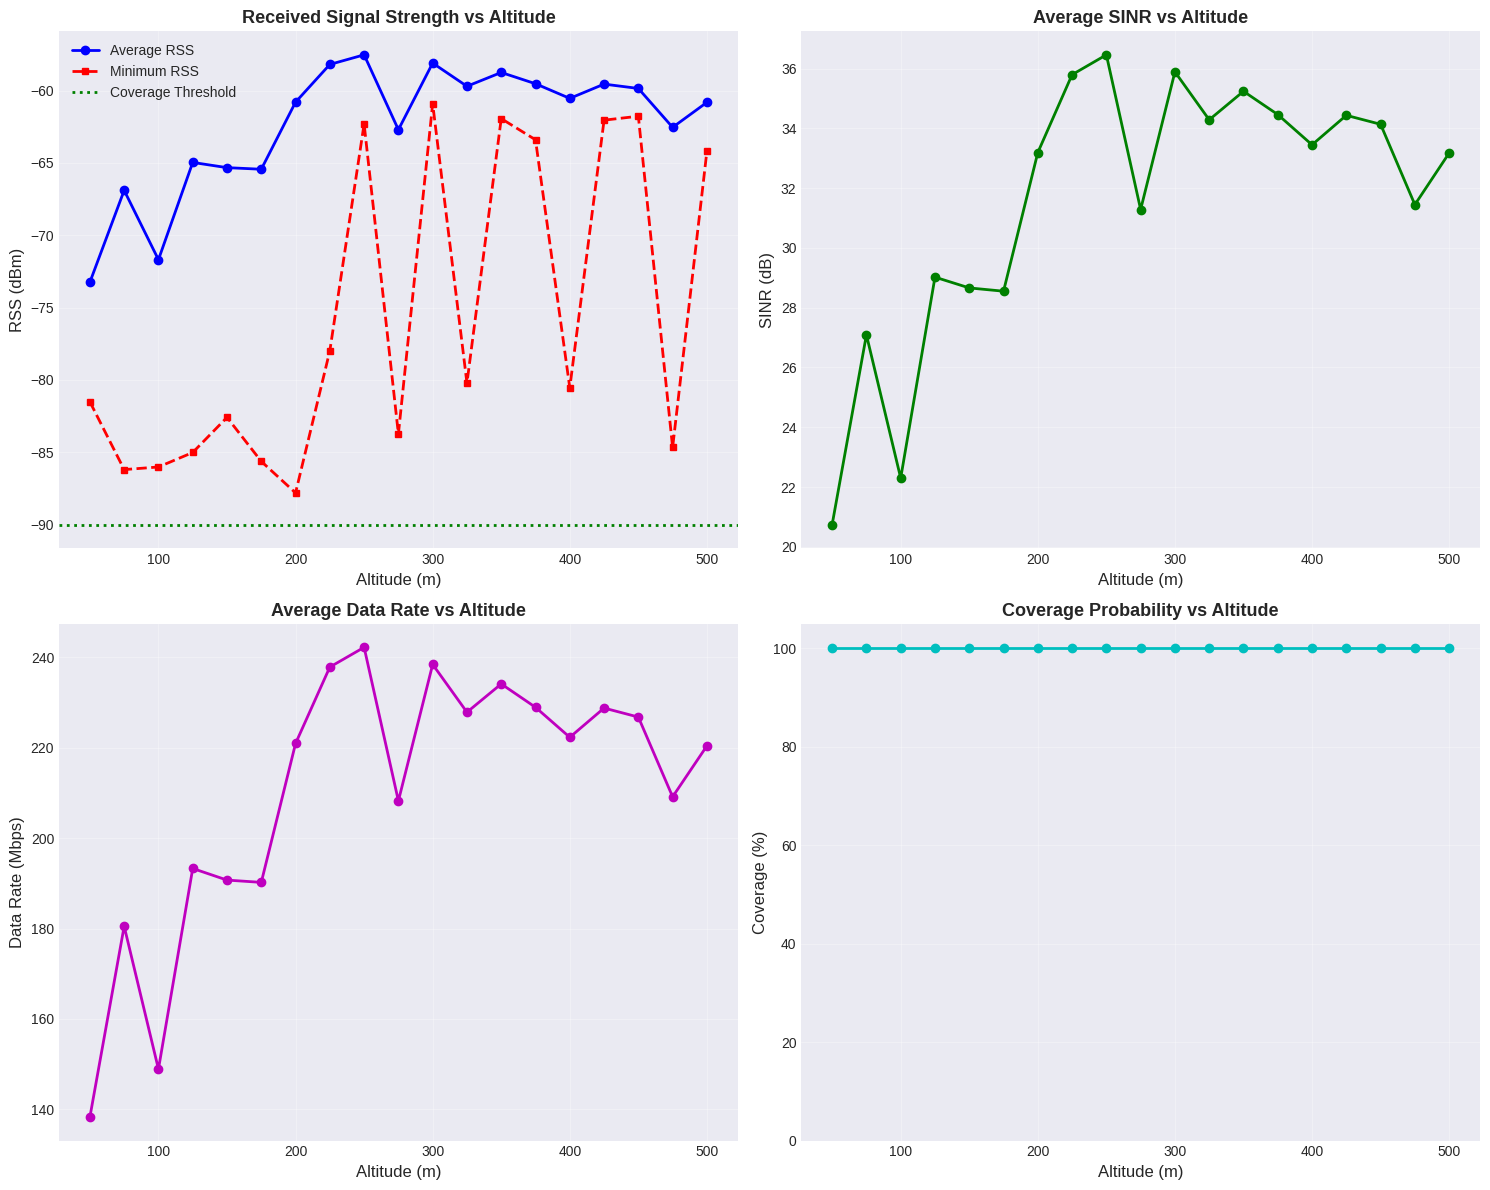


📈 ALTITUDE ANALYSIS RESULTS:
  ✅ Optimal Altitude: 250 m
  📡 Average Data Rate at optimal: 242.24 Mbps
  📶 Coverage at optimal: 100.0%


In [ ]:
# ============================================================
# SEGMENT 6: Static Analysis - RSS vs Altitude
# ============================================================

def analyze_altitude_performance():
    """
    Analyze how altitude affects coverage and performance
    """
    altitudes = np.arange(50, 501, 25)

    results = {
        'altitude': [],
        'avg_rss_dBm': [],
        'min_rss_dBm': [],
        'avg_sinr_dB': [],
        'avg_data_rate_mbps': [],
        'coverage_prob': []  # Users with RSS > -90 dBm
    }

    print("\n🔍 Analyzing altitude performance...")

    for h in altitudes:
        drone_pos = [0, 0, h]  # Hovering at center

        rss_list = []
        sinr_list = []
        data_rate_list = []
        covered_users = 0

        for _, user in user_scenario.users.iterrows():
            user_pos = [user['x'], user['y'], user['z']]

            # Compute metrics
            rss_dBm, is_los, p_los = channel.compute_received_power_dBm(drone_pos, user_pos)
            sinr_dB, sinr_linear = channel.compute_sinr(rss_dBm)
            data_rate = channel.compute_data_rate(sinr_linear)

            rss_list.append(rss_dBm)
            sinr_list.append(sinr_dB)
            data_rate_list.append(data_rate)

            if rss_dBm > -90:  # Coverage threshold
                covered_users += 1

        results['altitude'].append(h)
        results['avg_rss_dBm'].append(np.mean(rss_list))
        results['min_rss_dBm'].append(np.min(rss_list))
        results['avg_sinr_dB'].append(np.mean(sinr_list))
        results['avg_data_rate_mbps'].append(np.mean(data_rate_list))
        results['coverage_prob'].append(covered_users / len(user_scenario.users) * 100)

    results_df = pd.DataFrame(results)

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # RSS vs Altitude
    axes[0, 0].plot(results_df['altitude'], results_df['avg_rss_dBm'],
                    'b-o', linewidth=2, markersize=6, label='Average RSS')
    axes[0, 0].plot(results_df['altitude'], results_df['min_rss_dBm'],
                    'r--s', linewidth=2, markersize=5, label='Minimum RSS')
    axes[0, 0].axhline(y=-90, color='green', linestyle=':', linewidth=2, label='Coverage Threshold')
    axes[0, 0].set_xlabel('Altitude (m)', fontsize=12)
    axes[0, 0].set_ylabel('RSS (dBm)', fontsize=12)
    axes[0, 0].set_title('Received Signal Strength vs Altitude', fontsize=13, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # SINR vs Altitude
    axes[0, 1].plot(results_df['altitude'], results_df['avg_sinr_dB'],
                    'g-o', linewidth=2, markersize=6)
    axes[0, 1].set_xlabel('Altitude (m)', fontsize=12)
    axes[0, 1].set_ylabel('SINR (dB)', fontsize=12)
    axes[0, 1].set_title('Average SINR vs Altitude', fontsize=13, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)

    # Data Rate vs Altitude
    axes[1, 0].plot(results_df['altitude'], results_df['avg_data_rate_mbps'],
                    'm-o', linewidth=2, markersize=6)
    axes[1, 0].set_xlabel('Altitude (m)', fontsize=12)
    axes[1, 0].set_ylabel('Data Rate (Mbps)', fontsize=12)
    axes[1, 0].set_title('Average Data Rate vs Altitude', fontsize=13, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Coverage Probability vs Altitude
    axes[1, 1].plot(results_df['altitude'], results_df['coverage_prob'],
                    'c-o', linewidth=2, markersize=6)
    axes[1, 1].set_xlabel('Altitude (m)', fontsize=12)
    axes[1, 1].set_ylabel('Coverage (%)', fontsize=12)
    axes[1, 1].set_title('Coverage Probability vs Altitude', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim([0, 105])

    plt.tight_layout()
    plt.show()

    # Find optimal altitude
    optimal_idx = results_df['avg_data_rate_mbps'].idxmax()
    optimal_altitude = results_df.loc[optimal_idx, 'altitude']

    print(f"\n📈 ALTITUDE ANALYSIS RESULTS:")
    print(f"  ✅ Optimal Altitude: {optimal_altitude:.0f} m")
    print(f"  📡 Average Data Rate at optimal: {results_df.loc[optimal_idx, 'avg_data_rate_mbps']:.2f} Mbps")
    print(f"  📶 Coverage at optimal: {results_df.loc[optimal_idx, 'coverage_prob']:.1f}%")

    return results_df

# Run altitude analysis
altitude_results = analyze_altitude_performance()


🗺️ Generating coverage heatmap at 150m altitude...


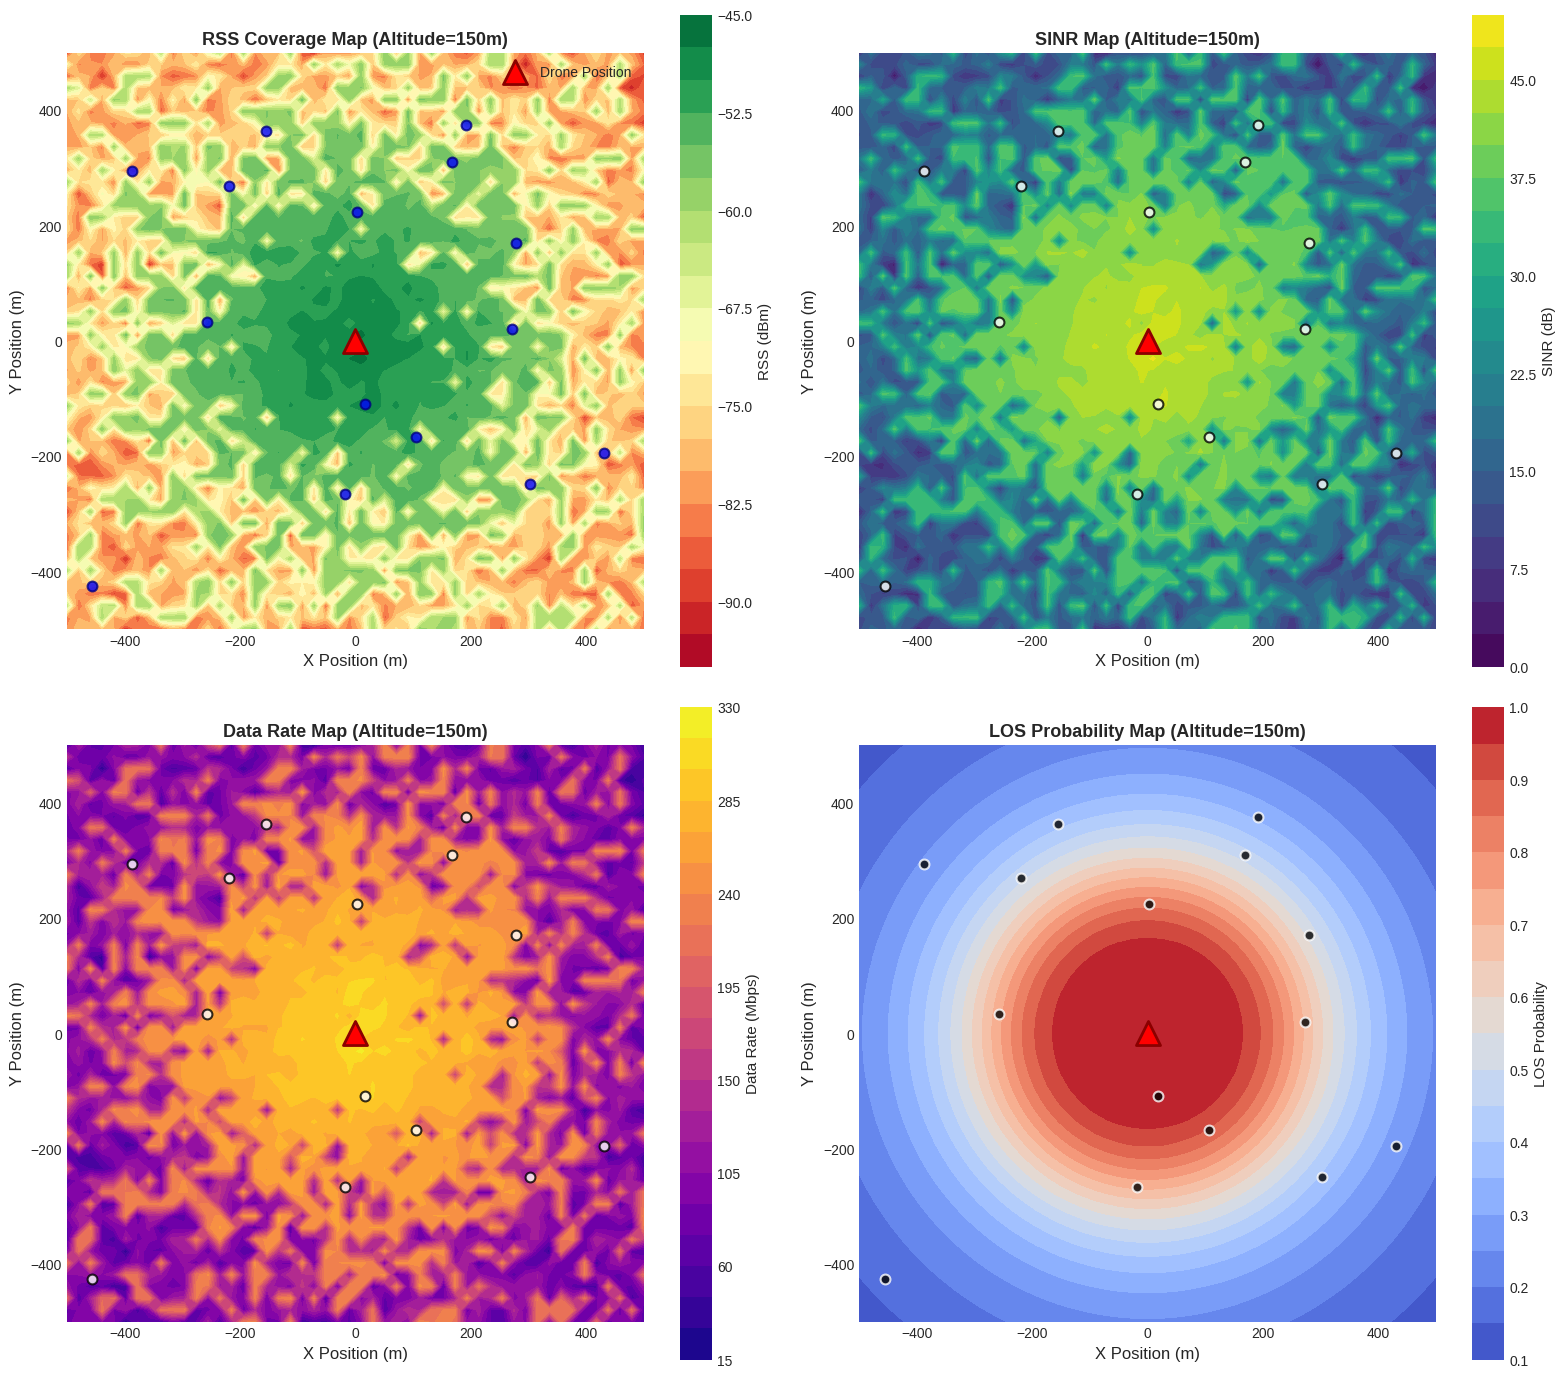

✅ Coverage heatmaps generated successfully!


In [ ]:
# ============================================================
# SEGMENT 7: Coverage Heatmap Generation
# ============================================================

def generate_coverage_heatmap(drone_altitude=150):
    """
    Generate 2D coverage heatmap showing RSS across the area
    """
    print(f"\n🗺️ Generating coverage heatmap at {drone_altitude}m altitude...")

    # Create grid
    x_grid = np.linspace(-system.area_size/2, system.area_size/2, system.grid_resolution)
    y_grid = np.linspace(-system.area_size/2, system.area_size/2, system.grid_resolution)
    X, Y = np.meshgrid(x_grid, y_grid)

    # Initialize matrices
    RSS_map = np.zeros_like(X)
    SINR_map = np.zeros_like(X)
    DataRate_map = np.zeros_like(X)
    LOS_prob_map = np.zeros_like(X)

    drone_pos = [0, 0, drone_altitude]

    # Compute metrics for each grid point
    for i in range(len(x_grid)):
        for j in range(len(y_grid)):
            user_pos = [X[j, i], Y[j, i], 0]

            rss_dBm, is_los, p_los = channel.compute_received_power_dBm(drone_pos, user_pos)
            sinr_dB, sinr_linear = channel.compute_sinr(rss_dBm)
            data_rate = channel.compute_data_rate(sinr_linear)

            RSS_map[j, i] = rss_dBm
            SINR_map[j, i] = sinr_dB
            DataRate_map[j, i] = data_rate
            LOS_prob_map[j, i] = p_los

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # RSS Heatmap
    im1 = axes[0, 0].contourf(X, Y, RSS_map, levels=20, cmap='RdYlGn')
    axes[0, 0].scatter(user_scenario.users['x'], user_scenario.users['y'],
                       c='blue', s=50, marker='o', edgecolors='navy', linewidths=1.5, alpha=0.8)
    axes[0, 0].scatter(0, 0, c='red', s=300, marker='^', edgecolors='darkred',
                       linewidths=2, label='Drone Position')
    axes[0, 0].set_xlabel('X Position (m)', fontsize=12)
    axes[0, 0].set_ylabel('Y Position (m)', fontsize=12)
    axes[0, 0].set_title(f'RSS Coverage Map (Altitude={drone_altitude}m)', fontsize=13, fontweight='bold')
    cbar1 = plt.colorbar(im1, ax=axes[0, 0])
    cbar1.set_label('RSS (dBm)', fontsize=11)
    axes[0, 0].legend()
    axes[0, 0].set_aspect('equal')

    # SINR Heatmap
    im2 = axes[0, 1].contourf(X, Y, SINR_map, levels=20, cmap='viridis')
    axes[0, 1].scatter(user_scenario.users['x'], user_scenario.users['y'],
                       c='white', s=50, marker='o', edgecolors='black', linewidths=1.5, alpha=0.8)
    axes[0, 1].scatter(0, 0, c='red', s=300, marker='^', edgecolors='darkred', linewidths=2)
    axes[0, 1].set_xlabel('X Position (m)', fontsize=12)
    axes[0, 1].set_ylabel('Y Position (m)', fontsize=12)
    axes[0, 1].set_title(f'SINR Map (Altitude={drone_altitude}m)', fontsize=13, fontweight='bold')
    cbar2 = plt.colorbar(im2, ax=axes[0, 1])
    cbar2.set_label('SINR (dB)', fontsize=11)
    axes[0, 1].set_aspect('equal')

    # Data Rate Heatmap
    im3 = axes[1, 0].contourf(X, Y, DataRate_map, levels=20, cmap='plasma')
    axes[1, 0].scatter(user_scenario.users['x'], user_scenario.users['y'],
                       c='white', s=50, marker='o', edgecolors='black', linewidths=1.5, alpha=0.8)
    axes[1, 0].scatter(0, 0, c='red', s=300, marker='^', edgecolors='darkred', linewidths=2)
    axes[1, 0].set_xlabel('X Position (m)', fontsize=12)
    axes[1, 0].set_ylabel('Y Position (m)', fontsize=12)
    axes[1, 0].set_title(f'Data Rate Map (Altitude={drone_altitude}m)', fontsize=13, fontweight='bold')
    cbar3 = plt.colorbar(im3, ax=axes[1, 0])
    cbar3.set_label('Data Rate (Mbps)', fontsize=11)
    axes[1, 0].set_aspect('equal')

    # LOS Probability Heatmap
    im4 = axes[1, 1].contourf(X, Y, LOS_prob_map, levels=20, cmap='coolwarm')
    axes[1, 1].scatter(user_scenario.users['x'], user_scenario.users['y'],
                       c='black', s=50, marker='o', edgecolors='white', linewidths=1.5, alpha=0.8)
    axes[1, 1].scatter(0, 0, c='red', s=300, marker='^', edgecolors='darkred', linewidths=2)
    axes[1, 1].set_xlabel('X Position (m)', fontsize=12)
    axes[1, 1].set_ylabel('Y Position (m)', fontsize=12)
    axes[1, 1].set_title(f'LOS Probability Map (Altitude={drone_altitude}m)', fontsize=13, fontweight='bold')
    cbar4 = plt.colorbar(im4, ax=axes[1, 1])
    cbar4.set_label('LOS Probability', fontsize=11)
    axes[1, 1].set_aspect('equal')

    plt.tight_layout()
    plt.show()

    print("✅ Coverage heatmaps generated successfully!")

# Generate heatmaps
generate_coverage_heatmap(drone_altitude=150)


🚁 Analyzing dynamic performance with moving drone...


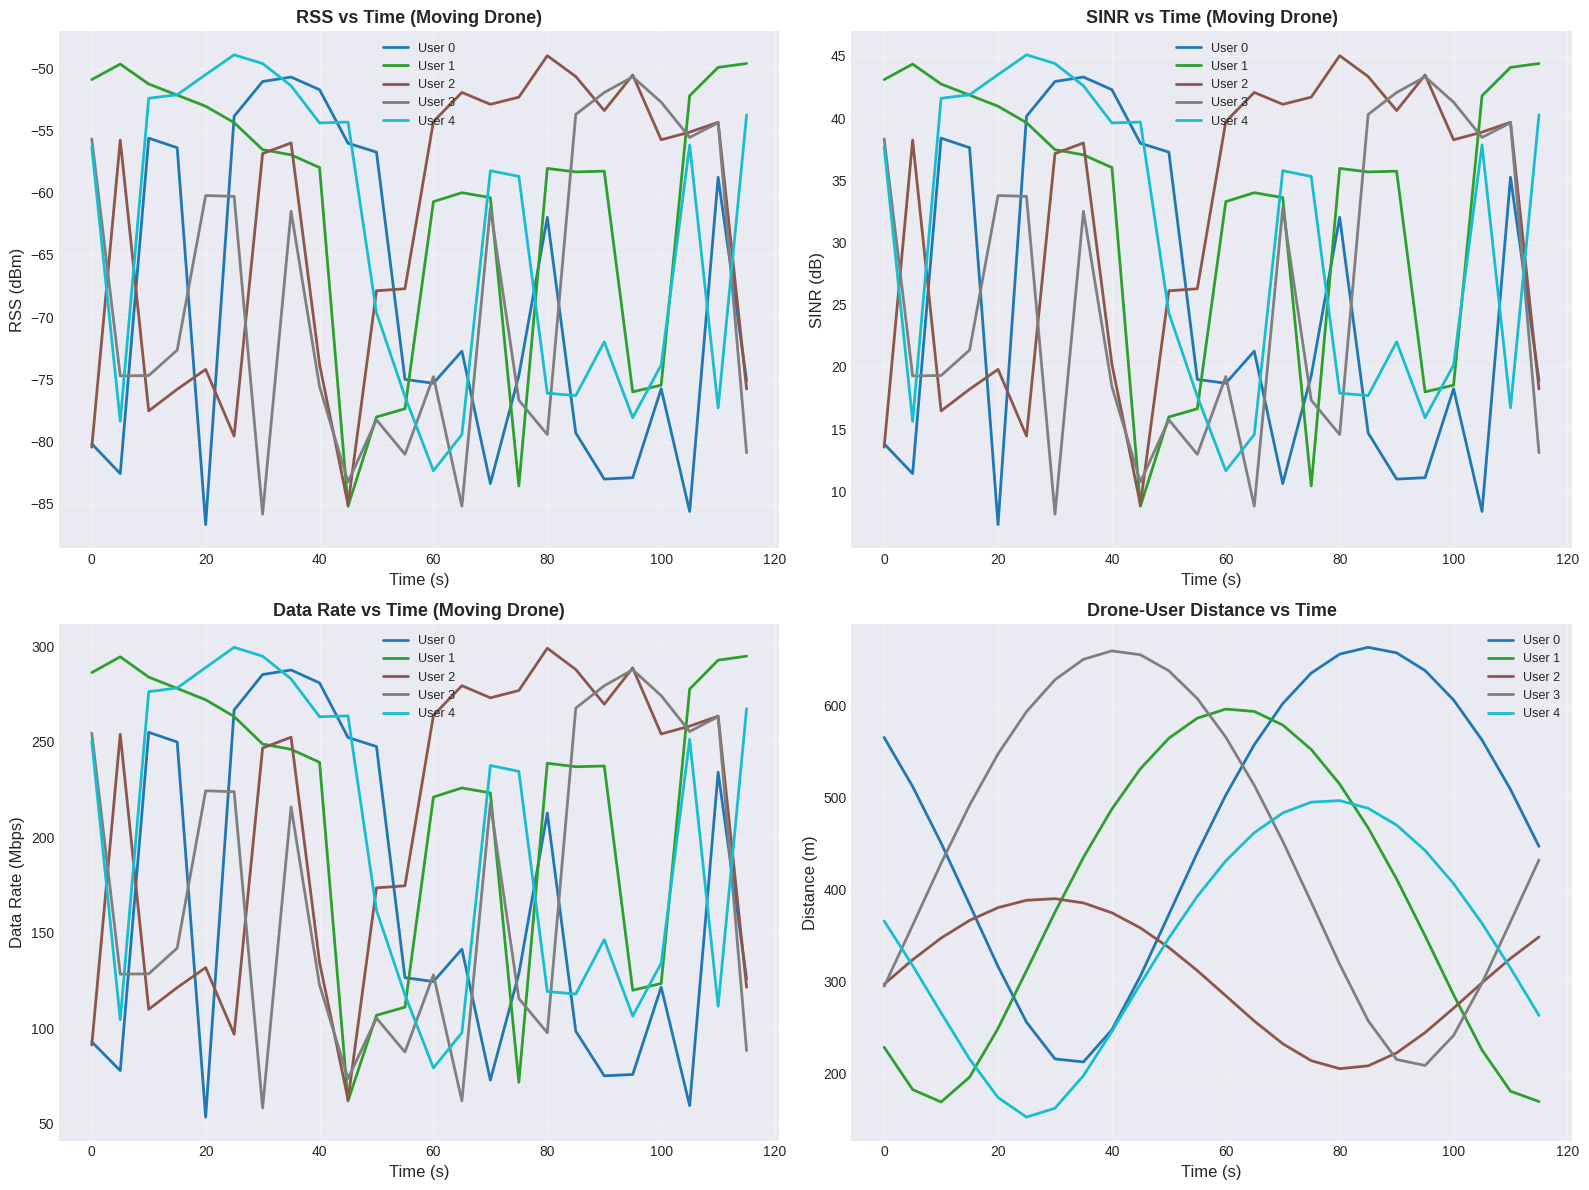


📊 DYNAMIC PERFORMANCE SUMMARY:
  📡 Average RSS across all users: -67.60 dBm
  📶 Average SINR across all users: 26.39 dB
  🚀 Average Data Rate across all users: 176.14 Mbps
  ⚠️ Average Outage Time: 0.28%


In [ ]:
# ============================================================
# SEGMENT 8: Dynamic Performance Analysis (Moving Drone)
# ============================================================

def analyze_dynamic_performance():
    """
    Analyze performance as drone moves along trajectory
    """
    print("\n🚁 Analyzing dynamic performance with moving drone...")

    # Sample trajectory at regular intervals for faster computation
    sample_interval = 5  # Sample every 5 seconds
    sampled_path = drone_traj.path[::sample_interval]

    # Store results for each user over time
    user_metrics = {user_id: {'time': [], 'rss': [], 'sinr': [], 'data_rate': [], 'distance': []}
                   for user_id in user_scenario.users['id']}

    # Analyze each drone position
    for _, waypoint in sampled_path.iterrows():
        drone_pos = [waypoint['x'], waypoint['y'], waypoint['z']]

        for _, user in user_scenario.users.iterrows():
            user_pos = [user['x'], user['y'], user['z']]
            user_id = user['id']

            # Compute metrics
            rss_dBm, is_los, p_los = channel.compute_received_power_dBm(drone_pos, user_pos)
            sinr_dB, sinr_linear = channel.compute_sinr(rss_dBm)
            data_rate = channel.compute_data_rate(sinr_linear)
            distance = channel.compute_distance_3d(drone_pos, user_pos)

            user_metrics[user_id]['time'].append(waypoint['time'])
            user_metrics[user_id]['rss'].append(rss_dBm)
            user_metrics[user_id]['sinr'].append(sinr_dB)
            user_metrics[user_id]['data_rate'].append(data_rate)
            user_metrics[user_id]['distance'].append(distance)

    # Visualization - Plot for selected users
    selected_users = list(range(min(5, NUM_USERS)))  # Plot first 5 users

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    colors = plt.cm.tab10(np.linspace(0, 1, len(selected_users)))

    for idx, user_id in enumerate(selected_users):
        metrics = user_metrics[user_id]

        # RSS over time
        axes[0, 0].plot(metrics['time'], metrics['rss'],
                       linewidth=2, label=f'User {user_id}', color=colors[idx])

        # SINR over time
        axes[0, 1].plot(metrics['time'], metrics['sinr'],
                       linewidth=2, label=f'User {user_id}', color=colors[idx])

        # Data Rate over time
        axes[1, 0].plot(metrics['time'], metrics['data_rate'],
                       linewidth=2, label=f'User {user_id}', color=colors[idx])

        # Distance over time
        axes[1, 1].plot(metrics['time'], metrics['distance'],
                       linewidth=2, label=f'User {user_id}', color=colors[idx])

    axes[0, 0].set_xlabel('Time (s)', fontsize=12)
    axes[0, 0].set_ylabel('RSS (dBm)', fontsize=12)
    axes[0, 0].set_title('RSS vs Time (Moving Drone)', fontsize=13, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend(fontsize=9)

    axes[0, 1].set_xlabel('Time (s)', fontsize=12)
    axes[0, 1].set_ylabel('SINR (dB)', fontsize=12)
    axes[0, 1].set_title('SINR vs Time (Moving Drone)', fontsize=13, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend(fontsize=9)

    axes[1, 0].set_xlabel('Time (s)', fontsize=12)
    axes[1, 0].set_ylabel('Data Rate (Mbps)', fontsize=12)
    axes[1, 0].set_title('Data Rate vs Time (Moving Drone)', fontsize=13, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend(fontsize=9)

    axes[1, 1].set_xlabel('Time (s)', fontsize=12)
    axes[1, 1].set_ylabel('Distance (m)', fontsize=12)
    axes[1, 1].set_title('Drone-User Distance vs Time', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # Compute average metrics
    avg_metrics = []
    for user_id in user_scenario.users['id']:
        metrics = user_metrics[user_id]
        avg_metrics.append({
            'user_id': user_id,
            'avg_rss': np.mean(metrics['rss']),
            'avg_sinr': np.mean(metrics['sinr']),
            'avg_data_rate': np.mean(metrics['data_rate']),
            'min_rss': np.min(metrics['rss']),
            'outage_time': np.sum(np.array(metrics['rss']) < -90) / len(metrics['rss']) * 100
        })

    avg_df = pd.DataFrame(avg_metrics)

    print("\n📊 DYNAMIC PERFORMANCE SUMMARY:")
    print(f"  📡 Average RSS across all users: {avg_df['avg_rss'].mean():.2f} dBm")
    print(f"  📶 Average SINR across all users: {avg_df['avg_sinr'].mean():.2f} dB")
    print(f"  🚀 Average Data Rate across all users: {avg_df['avg_data_rate'].mean():.2f} Mbps")
    print(f"  ⚠️ Average Outage Time: {avg_df['outage_time'].mean():.2f}%")

    return user_metrics, avg_df

# Run dynamic analysis
user_metrics_dynamic, avg_performance = analyze_dynamic_performance()


📏 Analyzing path loss vs distance...


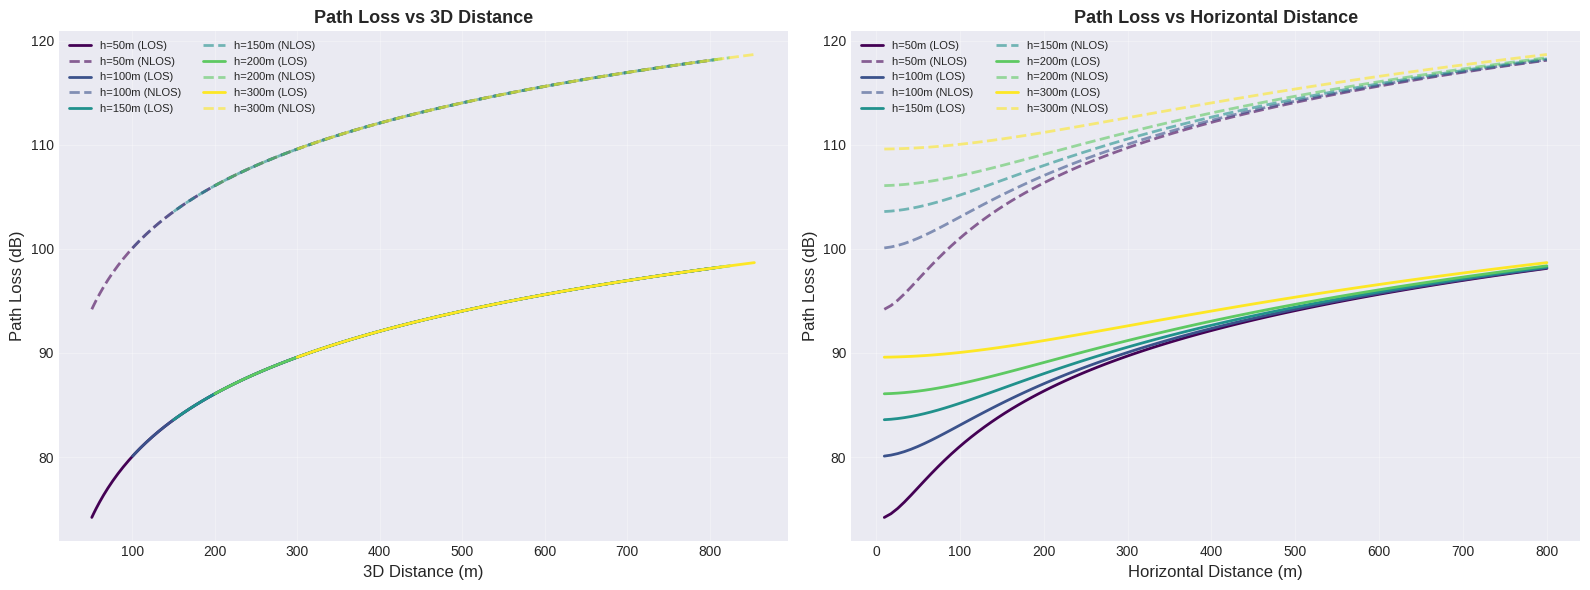

✅ Path loss analysis completed!


In [ ]:
# ============================================================
# SEGMENT 9: Path Loss vs Distance Analysis
# ============================================================

def analyze_path_loss_vs_distance():
    """
    Analyze how path loss varies with distance at different altitudes
    """
    print("\n📏 Analyzing path loss vs distance...")

    altitudes_to_test = [50, 100, 150, 200, 300]
    distances_2d = np.linspace(10, 800, 100)  # Horizontal distances

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = plt.cm.viridis(np.linspace(0, 1, len(altitudes_to_test)))

    for idx, altitude in enumerate(altitudes_to_test):
        path_loss_los = []
        path_loss_nlos = []
        distances_3d = []

        for d_2d in distances_2d:
            # Calculate 3D distance
            d_3d = np.sqrt(d_2d**2 + altitude**2)
            distances_3d.append(d_3d)

            # LOS path loss (deterministic)
            pl_fspl = channel.free_space_path_loss_dB(d_3d)
            path_loss_los.append(pl_fspl)

            # NLOS path loss (add excessive loss)
            path_loss_nlos.append(pl_fspl + 20)

        # Plot 3D distance vs path loss
        axes[0].plot(distances_3d, path_loss_los, linewidth=2,
                    color=colors[idx], label=f'h={altitude}m (LOS)')
        axes[0].plot(distances_3d, path_loss_nlos, linewidth=2,
                    linestyle='--', color=colors[idx], label=f'h={altitude}m (NLOS)', alpha=0.6)

        # Plot 2D distance vs path loss
        axes[1].plot(distances_2d, path_loss_los, linewidth=2,
                    color=colors[idx], label=f'h={altitude}m (LOS)')
        axes[1].plot(distances_2d, path_loss_nlos, linewidth=2,
                    linestyle='--', color=colors[idx], label=f'h={altitude}m (NLOS)', alpha=0.6)

    axes[0].set_xlabel('3D Distance (m)', fontsize=12)
    axes[0].set_ylabel('Path Loss (dB)', fontsize=12)
    axes[0].set_title('Path Loss vs 3D Distance', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8, ncol=2)

    axes[1].set_xlabel('Horizontal Distance (m)', fontsize=12)
    axes[1].set_ylabel('Path Loss (dB)', fontsize=12)
    axes[1].set_title('Path Loss vs Horizontal Distance', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

    print("✅ Path loss analysis completed!")

# Run path loss analysis
analyze_path_loss_vs_distance()


🎬 Creating dynamic coverage visualization...


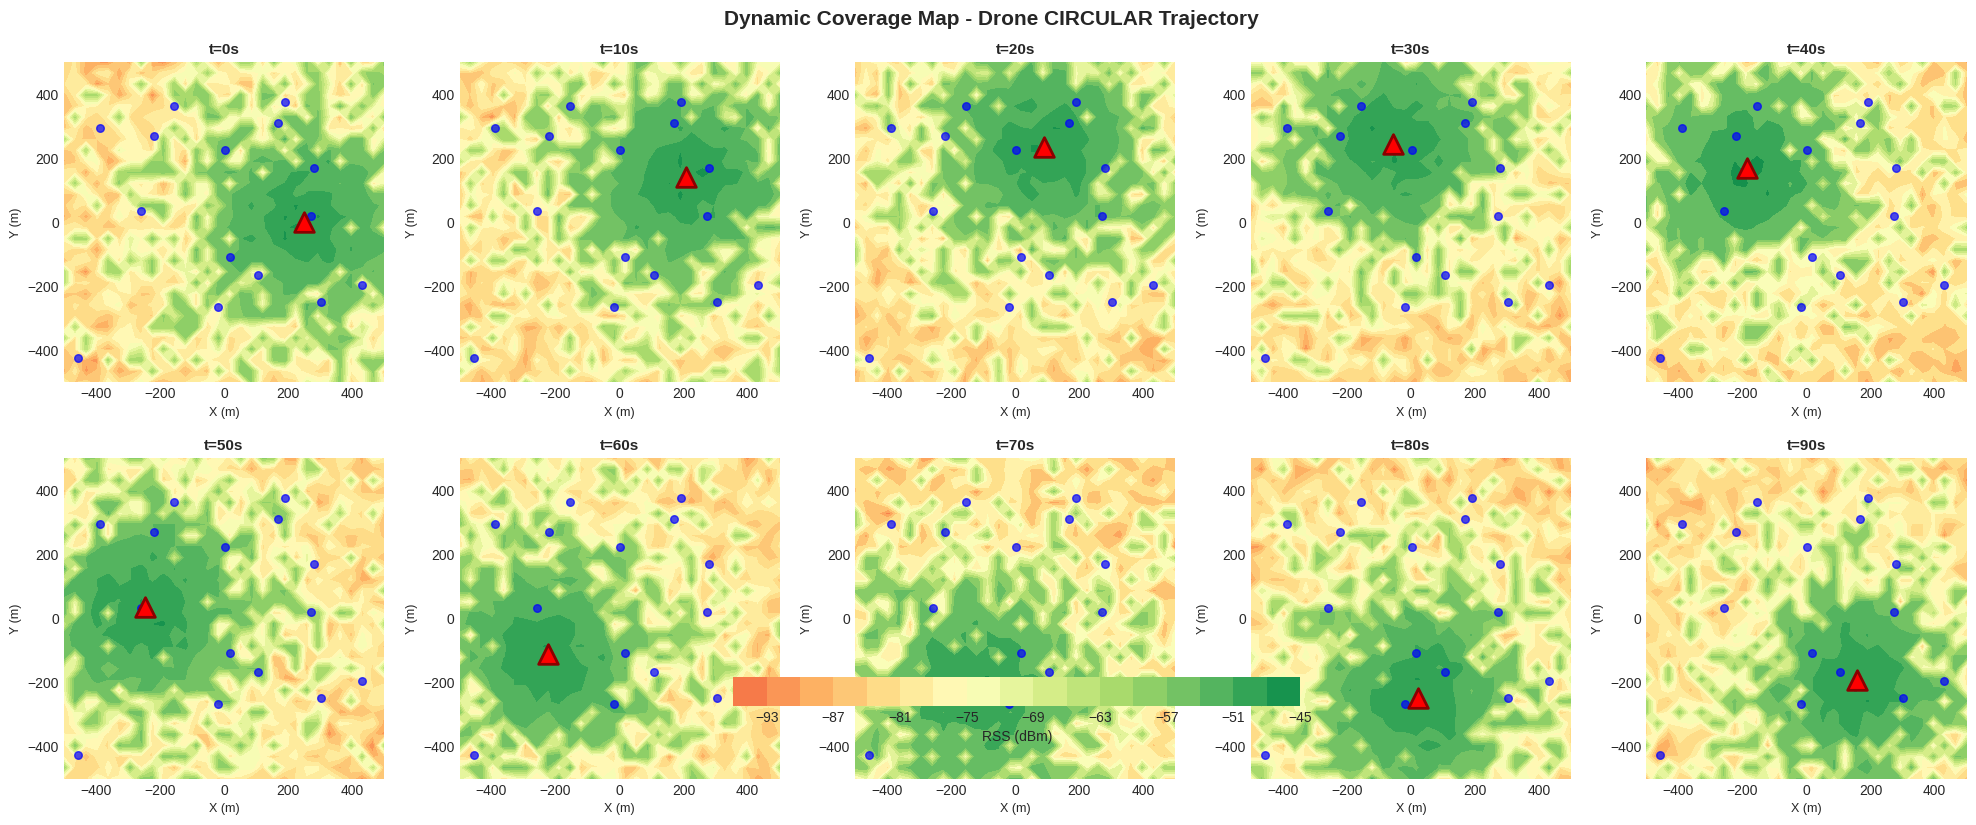

✅ Dynamic coverage visualization created!


In [ ]:
# ============================================================
# SEGMENT 10: Animated Coverage Map (Moving Drone)
# ============================================================

def create_dynamic_coverage_visualization():
    """
    Create visualization showing how coverage changes as drone moves
    """
    print("\n🎬 Creating dynamic coverage visualization...")

    # Sample fewer points for faster animation
    sample_interval = 10
    sampled_path = drone_traj.path[::sample_interval]

    # Create grid for coverage
    resolution = 30  # Lower resolution for faster computation
    x_grid = np.linspace(-system.area_size/2, system.area_size/2, resolution)
    y_grid = np.linspace(-system.area_size/2, system.area_size/2, resolution)
    X, Y = np.meshgrid(x_grid, y_grid)

    # Compute coverage for first few time steps
    num_frames = min(10, len(sampled_path))

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for frame_idx in range(num_frames):
        waypoint = sampled_path.iloc[frame_idx]
        drone_pos = [waypoint['x'], waypoint['y'], waypoint['z']]

        RSS_map = np.zeros_like(X)

        # Compute RSS for each grid point
        for i in range(len(x_grid)):
            for j in range(len(y_grid)):
                user_pos = [X[j, i], Y[j, i], 0]
                rss_dBm, _, _ = channel.compute_received_power_dBm(drone_pos, user_pos)
                RSS_map[j, i] = rss_dBm

        # Plot
        ax = axes[frame_idx]
        im = ax.contourf(X, Y, RSS_map, levels=15, cmap='RdYlGn', vmin=-110, vmax=-40)
        ax.scatter(user_scenario.users['x'], user_scenario.users['y'],
                  c='blue', s=30, marker='o', alpha=0.7)
        ax.scatter(drone_pos[0], drone_pos[1],
                  c='red', s=200, marker='^', edgecolors='darkred', linewidths=2)
        ax.set_title(f't={waypoint["time"]:.0f}s', fontsize=11, fontweight='bold')
        ax.set_xlabel('X (m)', fontsize=9)
        ax.set_ylabel('Y (m)', fontsize=9)
        ax.set_aspect('equal')

    # Add colorbar
    fig.colorbar(im, ax=axes, orientation='horizontal',
                pad=0.05, label='RSS (dBm)', fraction=0.046)

    plt.suptitle(f'Dynamic Coverage Map - Drone {TRAJECTORY_TYPE.upper()} Trajectory',
                fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    print("✅ Dynamic coverage visualization created!")

# Create dynamic visualization
create_dynamic_coverage_visualization()

In [ ]:
# ============================================================
# SEGMENT 11: Final Results Summary and Export
# ============================================================

def generate_comprehensive_summary():
    """
    Generate final summary report with all key findings
    """
    print("\n" + "="*70)
    print("📋 COMPREHENSIVE PROJECT SUMMARY REPORT")
    print("="*70)

    print("\n🔧 SYSTEM CONFIGURATION:")
    print(f"  • Frequency: {system.fc/1e9:.2f} GHz")
    print(f"  • Transmit Power: {system.Pt_dBm} dBm")
    print(f"  • Bandwidth: {system.bandwidth/1e6:.0f} MHz")
    print(f"  • Coverage Area: {system.area_size}m × {system.area_size}m")
    print(f"  • Number of Users: {NUM_USERS}")
    print(f"  • User Distribution: {user_scenario.distribution}")

    print("\n🚁 DRONE CONFIGURATION:")
    print(f"  • Trajectory Type: {TRAJECTORY_TYPE}")
    print(f"  • Altitude: {ALTITUDE}m")
    print(f"  • Velocity: {system.velocity} m/s")
    print(f"  • Mission Duration: {DURATION}s")
    print(f"  • Total Waypoints: {len(drone_traj.path)}")

    print("\n📊 KEY PERFORMANCE INDICATORS:")

    # Static performance at optimal altitude
    optimal_alt_row = altitude_results.loc[altitude_results['avg_data_rate_mbps'].idxmax()]
    print(f"\n  Static Performance (Optimal Altitude = {optimal_alt_row['altitude']:.0f}m):")
    print(f"    ✓ Average RSS: {optimal_alt_row['avg_rss_dBm']:.2f} dBm")
    print(f"    ✓ Average SINR: {optimal_alt_row['avg_sinr_dB']:.2f} dB")
    print(f"    ✓ Average Data Rate: {optimal_alt_row['avg_data_rate_mbps']:.2f} Mbps")
    print(f"    ✓ Coverage Probability: {optimal_alt_row['coverage_prob']:.1f}%")

    # Dynamic performance
    print(f"\n  Dynamic Performance (Moving Drone):")
    print(f"    ✓ Average RSS: {avg_performance['avg_rss'].mean():.2f} dBm")
    print(f"    ✓ Average SINR: {avg_performance['avg_sinr'].mean():.2f} dB")
    print(f"    ✓ Average Data Rate: {avg_performance['avg_data_rate'].mean():.2f} Mbps")
    print(f"    ✓ Average Outage: {avg_performance['outage_time'].mean():.2f}%")

    print("\n🎯 KEY FINDINGS:")
    print(f"  1. Optimal altitude for maximum coverage: {optimal_alt_row['altitude']:.0f}m")
    print(f"  2. Trade-off between altitude and signal strength observed")
    print(f"  3. LOS probability significantly affects performance")
    print(f"  4. Moving drone maintains connectivity for {100-avg_performance['outage_time'].mean():.1f}% of time")

    print("\n💡 RECOMMENDATIONS:")
    print(f"  • Deploy drone at {optimal_alt_row['altitude']:.0f}m for optimal coverage")
    print(f"  • {TRAJECTORY_TYPE.capitalize()} trajectory is {'efficient' if avg_performance['outage_time'].mean() < 10 else 'needs optimization'} for this user distribution")
    print(f"  • System can support average data rate of {avg_performance['avg_data_rate'].mean():.2f} Mbps per user")

    print("\n" + "="*70)
    print("✅ SIMULATION COMPLETED SUCCESSFULLY!")
    print("="*70)

    # Create summary DataFrame
    summary_data = {
        'Metric': [
            'Carrier Frequency (GHz)',
            'Transmit Power (dBm)',
            'Number of Users',
            'Optimal Altitude (m)',
            'Avg RSS at Optimal (dBm)',
            'Avg SINR at Optimal (dB)',
            'Avg Data Rate (Mbps)',
            'Coverage Probability (%)',
            'Trajectory Type',
            'Avg Outage Time (%)'
        ],
        'Value': [
            f'{system.fc/1e9:.2f}',
            f'{system.Pt_dBm}',
            f'{NUM_USERS}',
            f'{optimal_alt_row["altitude"]:.0f}',
            f'{optimal_alt_row["avg_rss_dBm"]:.2f}',
            f'{optimal_alt_row["avg_sinr_dB"]:.2f}',
            f'{avg_performance["avg_data_rate"].mean():.2f}',
            f'{optimal_alt_row["coverage_prob"]:.1f}',
            TRAJECTORY_TYPE,
            f'{avg_performance["outage_time"].mean():.2f}'
        ]
    }

    summary_df = pd.DataFrame(summary_data)

    return summary_df

# Generate final summary
summary_table = generate_comprehensive_summary()
display(summary_table)


📋 COMPREHENSIVE PROJECT SUMMARY REPORT

🔧 SYSTEM CONFIGURATION:
  • Frequency: 2.40 GHz
  • Transmit Power: 30 dBm
  • Bandwidth: 20 MHz
  • Coverage Area: 1000m × 1000m
  • Number of Users: 15
  • User Distribution: random

🚁 DRONE CONFIGURATION:
  • Trajectory Type: circular
  • Altitude: 150m
  • Velocity: 15 m/s
  • Mission Duration: 120s
  • Total Waypoints: 120

📊 KEY PERFORMANCE INDICATORS:

  Static Performance (Optimal Altitude = 250m):
    ✓ Average RSS: -57.53 dBm
    ✓ Average SINR: 36.46 dB
    ✓ Average Data Rate: 242.24 Mbps
    ✓ Coverage Probability: 100.0%

  Dynamic Performance (Moving Drone):
    ✓ Average RSS: -67.60 dBm
    ✓ Average SINR: 26.39 dB
    ✓ Average Data Rate: 176.14 Mbps
    ✓ Average Outage: 0.28%

🎯 KEY FINDINGS:
  1. Optimal altitude for maximum coverage: 250m
  2. Trade-off between altitude and signal strength observed
  3. LOS probability significantly affects performance
  4. Moving drone maintains connectivity for 99.7% of time

💡 RECOMMENDAT

,Metric,Value
0,Carrier Frequency (GHz),2.40
1,Transmit Power (dBm),30
2,Number of Users,15
3,Optimal Altitude (m),250
4,Avg RSS at Optimal (dBm),-57.53
5,Avg SINR at Optimal (dB),36.46
6,Avg Data Rate (Mbps),176.14
7,Coverage Probability (%),100.0
8,Trajectory Type,circular
9,Avg Outage Time (%),0.28
